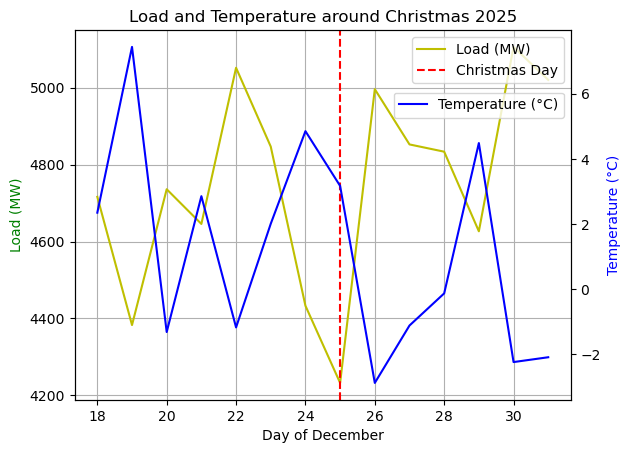

In [14]:
from matplotlib import pyplot as plt
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(christmas_data.index.day, christmas_data['load_mw'], 'y-', label='Load (MW)')
ax2.plot(christmas_data.index.day, christmas_data['temp'], 'b-', label='Temperature (°C)')
ax1.set_xlabel('Day of December')
ax1.set_ylabel('Load (MW)', color='g')
ax2.set_ylabel('Temperature (°C)', color='b')
ax1.set_title(f'Load and Temperature around Christmas {year}')
ax2.legend(loc='upper right', bbox_to_anchor=(1, 0.85))
# add a vertical line at day 25
ax1.axvline(x=25, color='r', linestyle='--', label='Christmas Day')
ax1.legend(loc='upper right')
ax1.grid(True)


In [ ]:
import pandas as pd
from load import create_dataset
from features import build_features
from models import NaiveMLR, rolling_forecast, evaluate_forecast, compute_metrics

peco_coords_dict = {
    "PHL": (39.872, -75.241),
    "KOP": (40.096, -75.385),
    "West_Chester": (39.960, -75.605),
    "Coatesville": (39.983, -75.823),
    "Doylestown": (40.310, -75.130),
    "Pottstown": (40.245, -75.649),
    "Quakertown": (40.441, -75.340),
    "Levittown": (40.155, -74.855)
}

# ── Load real data: train on 2016-2022, test on 2023 ─────────────────────────
# Uses Open-Meteo ERA5 weather (cached after first fetch)
df = create_dataset("hrl_load_metered_combined.csv", "PE", LAT, LON)

df_train = df.loc["2016":"2022"]
df_test  = df.loc["2023"]

print(f"Train: {df_train.index[0].date()} → {df_train.index[-1].date()}  ({len(df_train):,} rows)")
print(f"Test : {df_test.index[0].date()}  → {df_test.index[-1].date()}  ({len(df_test):,} rows)")
print(f"NaNs in train temp: {df_train['temp'].isna().sum()}")
print(f"NaNs in test  temp: {df_test['temp'].isna().sum()}")

# ── 1. Feature matrix sanity check ───────────────────────────────────────────
X_train, y_train = build_features(df_train)
print(f"\nX_train shape : {X_train.shape}  (expect 281 cols)")
assert X_train.shape[1] == 281

# ── 2. Single fit → predict full test year ───────────────────────────────────
model = NaiveMLR()
preds = model.fit_predict(df_train, df_test)

metrics = compute_metrics(df_test["load_mw"], preds)
print("\n── Single-fit metrics (train 2016-22, test 2023) ──")
for k, v in metrics.items():
    print(f"  {k:6s}: {v:.3f}")

# # ── 3. Rolling forecast on 2023 (retrain each day) ───────────────────────────
# # Note: this retrains 365 times — takes a few minutes on real data
# results = rolling_forecast(
#     df,
#     forecast_start=pd.Timestamp("2023-01-01"),
#     forecast_end=pd.Timestamp("2023-12-31"),
# )

# print("\n── Rolling forecast metrics (2023) ──")
# roll_metrics = evaluate_forecast(results)
# for k, v in roll_metrics.items():
#     print(f"  {k:6s}: {v:.3f}")

# # ── 4. Breakdown by month ─────────────────────────────────────────────────────
# from models import compute_metrics
# monthly = compute_metrics(results["load_mw_actual"], results["load_mw_pred"], groupby="month")
# print("\n── MAPE by month (rolling) ──")
# months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
# for m, name in enumerate(months, start=1):
#     if m in monthly:
#         print(f"  {name}: {monthly[m]['MAPE']:.2f}%")


Loading PJM data from hrl_load_metered_combined.csv...


Loaded 87662 rows for Zone: PE
Fetching weather data via Open-Meteo (ERA5 Reanalysis)...
Fetched 87672 weather rows (Open-Meteo).
Train: 2016-01-01 → 2022-12-31  (61,368 rows)
Test : 2023-01-01  → 2023-12-31  (8,760 rows)
NaNs in train temp: 0
NaNs in test  temp: 0

X_train shape : (61368, 281)  (expect 281 cols)

── Single-fit metrics (train 2016-22, test 2023) ──
  MAE   : 192.360
  RMSE  : 286.305
  MAPE  : 4.366
  CVRMSE: 6.739


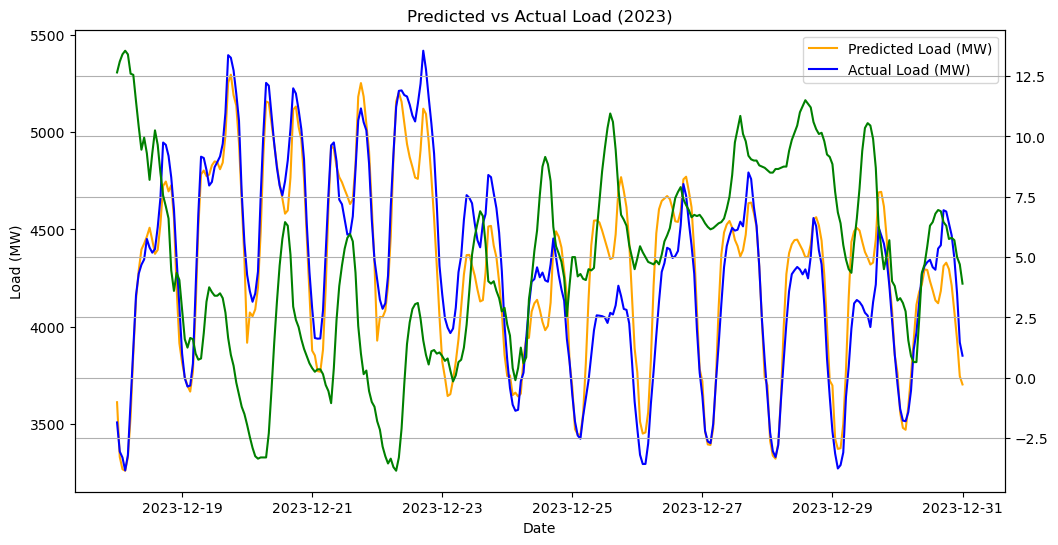

In [8]:
import matplotlib.pyplot as plt
start_time = pd.Timestamp("2023-12-18")
end_time = pd.Timestamp("2023-12-31")
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(preds[start_time:end_time], label="Predicted Load (MW)", color='orange')
ax2 = ax.twinx()
ax2.plot(df_test["temp"][start_time:end_time], label="Temperature (°C)", color='green')
ax.plot(df_test["load_mw"][start_time:end_time], label="Actual Load (MW)", color='blue')
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.set_title("Predicted vs Actual Load (2023)")
ax.legend()
plt.grid(True)
plt.show()

In [3]:

# ── Benchmark: compare weather location × season ─────────────────────────────
import pandas as pd
from load import create_dataset
from models import NaiveMLR, compute_metrics

SEASONS = {
    'Winter': [12, 1, 2],
    'Spring': [3, 4, 5],
    'Summer': [6, 7, 8],
    'Fall':   [9, 10, 11],
}

peco_coords_dict = {
    "PHL":         (39.877, -75.225),
    "KOP":         (40.097, -75.386),
    "West_Chester":(39.960, -75.605),
    "Coatesville": (39.983, -75.826),
    "Doylestown":  (40.310, -75.130),
    "Pottstown":   (40.245, -75.649),
    "Quakertown":  (40.441, -75.344),
    "Levittown":   (40.155, -74.830),
}

records = []
for loc_name, (lat, lon) in peco_coords_dict.items():
    print(f"Running {loc_name} ({lat}, {lon})...")
    df_loc   = create_dataset("hrl_load_metered_combined.csv", "PE", lat, lon)
    df_train = df_loc.loc["2016":"2022"]
    df_test  = df_loc.loc["2023"]

    model = NaiveMLR()
    preds = model.fit_predict(df_train, df_test)

    overall = compute_metrics(df_test["load_mw"], preds)

    row = {
        "Location": loc_name,
        "MAE":    round(overall["MAE"],    1),
        "RMSE":   round(overall["RMSE"],   1),
        "MAPE":   round(overall["MAPE"],   3),
        "CVRMSE": round(overall["CVRMSE"], 3),
    }
    for season, months in SEASONS.items():
        mask = df_test.index.month.isin(months)
        m = compute_metrics(df_test.loc[mask, "load_mw"], preds[mask])
        row[f"MAPE_{season}"] = round(m["MAPE"], 3)

    records.append(row)

results_df = pd.DataFrame(records).set_index("Location")
print("\nDone.")
results_df


Running PHL (39.877, -75.225)...
Loading PJM data from hrl_load_metered_combined.csv...


Loaded 87662 rows for Zone: PE
Fetching weather data via Open-Meteo (ERA5 Reanalysis)...
Fetched 87672 weather rows (Open-Meteo).
Running KOP (40.097, -75.386)...
Loading PJM data from hrl_load_metered_combined.csv...


Loaded 87662 rows for Zone: PE
Fetching weather data via Open-Meteo (ERA5 Reanalysis)...
Fetched 87672 weather rows (Open-Meteo).
Running West_Chester (39.96, -75.605)...
Loading PJM data from hrl_load_metered_combined.csv...


Loaded 87662 rows for Zone: PE
Fetching weather data via Open-Meteo (ERA5 Reanalysis)...
Fetched 87672 weather rows (Open-Meteo).
Running Coatesville (39.983, -75.826)...
Loading PJM data from hrl_load_metered_combined.csv...


Loaded 87662 rows for Zone: PE
Fetching weather data via Open-Meteo (ERA5 Reanalysis)...
Fetched 87672 weather rows (Open-Meteo).
Running Doylestown (40.31, -75.13)...
Loading PJM data from hrl_load_metered_combined.csv...


Loaded 87662 rows for Zone: PE
Fetching weather data via Open-Meteo (ERA5 Reanalysis)...
Fetched 87672 weather rows (Open-Meteo).
Running Pottstown (40.245, -75.649)...
Loading PJM data from hrl_load_metered_combined.csv...


Loaded 87662 rows for Zone: PE
Fetching weather data via Open-Meteo (ERA5 Reanalysis)...
Fetched 87672 weather rows (Open-Meteo).
Running Quakertown (40.441, -75.344)...
Loading PJM data from hrl_load_metered_combined.csv...


Loaded 87662 rows for Zone: PE
Fetching weather data via Open-Meteo (ERA5 Reanalysis)...
Fetched 87672 weather rows (Open-Meteo).
Running Levittown (40.155, -74.83)...
Loading PJM data from hrl_load_metered_combined.csv...


Loaded 87662 rows for Zone: PE
Fetching weather data via Open-Meteo (ERA5 Reanalysis)...
Fetched 87672 weather rows (Open-Meteo).

Done.


,MAE,RMSE,MAPE,CVRMSE,MAPE_Winter,MAPE_Spring,MAPE_Summer,MAPE_Fall
Location,,,,,,,,
PHL,198.9,297.0,4.465,6.990,3.301,3.637,6.531,4.364
KOP,190.0,283.1,4.312,6.662,3.396,3.927,5.664,4.241
West_Chester,192.5,286.5,4.369,6.743,3.415,3.981,5.799,4.257
Coatesville,194.2,288.5,4.404,6.791,3.461,3.979,5.950,4.206
Doylestown,186.4,276.4,4.243,6.506,3.422,3.865,5.555,4.112
Pottstown,194.0,291.8,4.406,6.869,3.429,4.056,5.834,4.282
Quakertown,190.0,282.7,4.331,6.653,3.438,4.115,5.569,4.182
Levittown,184.2,268.8,4.186,6.327,3.385,3.725,5.484,4.133


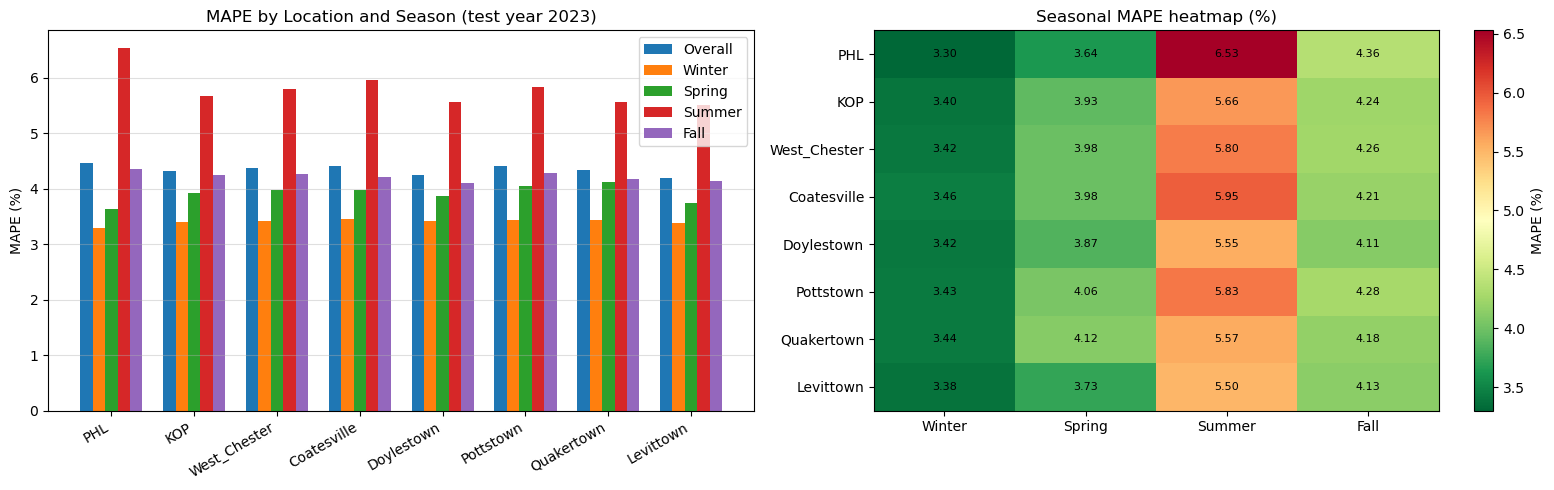

In [2]:

# ── Visualise: overall MAPE + seasonal heatmap ───────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

season_cols = [f"MAPE_{s}" for s in SEASONS]
season_labels = list(SEASONS.keys())
locations = results_df.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: grouped bar chart (overall + 4 seasons) ────────────────────────────
bar_cols  = ["MAPE"] + season_cols
bar_names = ["Overall"] + season_labels
x = np.arange(len(locations))
width = 0.15

for i, (col, name) in enumerate(zip(bar_cols, bar_names)):
    offset = (i - len(bar_cols) / 2 + 0.5) * width
    axes[0].bar(x + offset, results_df[col], width, label=name)

axes[0].set_xticks(x)
axes[0].set_xticklabels(locations, rotation=30, ha="right")
axes[0].set_ylabel("MAPE (%)")
axes[0].set_title("MAPE by Location and Season (test year 2023)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.4)

# ── Right: heatmap of seasonal MAPE ──────────────────────────────────────────
data = results_df[season_cols].values
im = axes[1].imshow(data, aspect="auto", cmap="RdYlGn_r")
axes[1].set_xticks(range(len(season_labels)))
axes[1].set_xticklabels(season_labels)
axes[1].set_yticks(range(len(locations)))
axes[1].set_yticklabels(locations)
axes[1].set_title("Seasonal MAPE heatmap (%)")
plt.colorbar(im, ax=axes[1], label="MAPE (%)")

for r in range(len(locations)):
    for c in range(len(season_labels)):
        axes[1].text(c, r, f"{data[r, c]:.2f}", ha="center", va="center",
                     fontsize=8, color="black")

plt.tight_layout()
plt.show()


In [2]:
from load import create_dataset
locations = [
    ("Philadelphia", 39.95, -75.16),
    ("Harrisburg",   40.27, -76.88),
    ("Allentown",    40.65, -75.43),
]

df = create_dataset("hrl_load_metered_2018.csv", "PE", locations)
# Columns: load_mw, philadelphia_temp, philadelphia_dwpt, ..., harrisburg_temp, ...


Loading PJM data from hrl_load_metered_2018.csv...


Loaded 8759 rows for Zone: PE
Fetching weather data via Open-Meteo (ERA5 Reanalysis)...
Fetched 8760 weather rows (Open-Meteo).
Fetching weather data via Open-Meteo (ERA5 Reanalysis)...
Fetched 8760 weather rows (Open-Meteo).
Fetching weather data via Open-Meteo (ERA5 Reanalysis)...
Fetched 8760 weather rows (Open-Meteo).


In [3]:
df.head()

,load_mw,philadelphia_temp,philadelphia_rh,philadelphia_dwpt,philadelphia_wspd,harrisburg_temp,harrisburg_rh,harrisburg_dwpt,harrisburg_wspd,allentown_temp,allentown_rh,allentown_dwpt,allentown_wspd
2018-01-01 00:00:00,5733.516,-12.4,45.028999,-21.900000,14.291592,-12.20,55.733967,-19.250000,7.421590,-13.95,48.650898,-22.450001,12.240000
2018-01-01 01:00:00,5639.903,-12.7,46.131504,-21.900000,13.493999,-12.65,59.291111,-18.950001,6.369050,-14.20,49.436802,-22.500000,12.240000
2018-01-01 02:00:00,5555.381,-13.0,46.851597,-22.000000,12.229406,-12.95,62.053894,-18.700001,6.130579,-14.35,49.827568,-22.549999,11.753877
2018-01-01 03:00:00,5527.837,-13.2,47.201103,-22.100000,12.229406,-13.15,63.876923,-18.549999,6.638072,-14.50,49.781155,-22.700001,10.636766
2018-01-01 04:00:00,5593.163,-13.4,47.554184,-22.200001,12.475961,-13.40,66.302505,-18.350000,6.297428,-14.60,49.970306,-22.750000,10.587917
